# 🚀 Proyecto de Machine Learning: Inteligencia de Negocios en Google Play Store
---
**Evaluación Parcial N°2 - Modelado, Optimización y Análisis de Datos**

**Integrantes:** Lorenzo Ruiz || Millaray Peñaloza  
**Asignatura:** Programación para la Ciencia de Datos (SCY1101)  
**Fecha:** 15 de mayo de 2026

---

## 📌 1. Contexto del Proyecto
En un mercado saturado con millones de aplicaciones, entender los factores que impulsan el éxito es crítico para desarrolladores y analistas de negocio. El presente cuaderno constituye la **Fase 2 (Modelado Avanzado)** del proyecto, donde se transforman los datos de la Google Play Store en conocimiento accionable mediante algoritmos de aprendizaje automático.

Este entorno de trabajo utiliza técnicas de Ciencia de Datos para segmentar el mercado y predecir el rendimiento de las aplicaciones, asegurando la robustez de los resultados mediante procesos de validación cruzada y optimización de hiperparámetros.

## 🎯 2. Objetivos Estratégicos
* **Segmentación de Mercado (Unsupervised Learning):** Utilizar agrupamiento mediante *K-Means* y reducción de dimensionalidad (*PCA*) para identificar perfiles naturales de aplicaciones.
* **Predicción de Éxito (Supervised Learning):** Desarrollar un sistema de clasificación binaria para predecir si una aplicación será "Exitosa" (Rating ≥ 4.3).
* **Ingeniería de Calidad:** Implementar *Pipelines* de procesamiento para evitar la fuga de datos (*Data Leakage*).
* **Interpretabilidad de Modelos:** Analizar la importancia de las variables para determinar los drivers reales del éxito.

## 🗂️ 3. Estructura Metodológica (Flujo de Trabajo)
Para asegurar un análisis riguroso y cumplir con los requerimientos académicos, el cuaderno se organiza en los siguientes bloques técnicos:

1. **Aprendizaje No Supervisado:** Identificación de perfiles de aplicaciones mediante K-Means y visualización con PCA.
2. **Preparación para Aprendizaje Supervisado:** Definición de la variable objetivo y división estratégica de datos (Train/Test Split).
3. **Construcción y Entrenamiento del Modelo:** Implementación de *Pipelines*, Validación Cruzada y ajuste fino de hiperparámetros mediante *GridSearchCV*.
4. **Evaluación del Modelo:** Análisis comparativo de métricas de desempeño (Accuracy, F1-Score).
5. **Visualización de Resultados:** Interpretación del modelo mediante Matrices de Confusión y gráficos de Importancia de Variables.
6. **Documentación y Presentación:** Síntesis de conclusiones y hallazgos finales del análisis.

---
*Nota: Este documento ha sido diseñado siguiendo estándares profesionales de documentación técnica y reproducibilidad de código.*



### 1. Aprendizaje No Supervisado: Agrupamiento (Clustering) y Reducción de Dimensionalidad
**¿Qué hace el código?**
Selecciona las variables numéricas del dataset, las estandariza, aplica el algoritmo K-Means para segmentar las aplicaciones en 3 clústeres y utiliza Análisis de Componentes Principales (PCA) para reducir las dimensiones y visualizar los grupos en un plano 2D.

**Justificación Técnica**
* **Escalamiento (`StandardScaler`):** Vital porque K-Means calcula distancias euclidianas; sin escalar, variables con magnitudes grandes (como `Installs`) sesgarían completamente el modelo.
* **PCA:** Permite visualizar relaciones multidimensionales (5 variables) en un formato bidimensional interpretable, facilitando la identificación de "perfiles" naturales de aplicaciones dentro del mercado sin depender de etiquetas previas.

In [13]:
#Impoertacion de liberias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Cargar datos
df = pd.read_csv('googleplaystore_limpio.csv')

print("Dataset y liberias cargados correctamente")


dataset y liberias cargados correctamente


### 1.1 Método del Codo (Elbow Method)
**¿Qué hace el código?**
Ejecuta el algoritmo K-Means varias veces (del 1 al 10) y calcula la "inercia" (la suma de las distancias al cuadrado dentro de cada grupo) para cada caso, graficando los resultados en una línea quebrada.

**Justificación Técnica**
* **Criterio de Selección:** El objetivo es encontrar el punto de "inflexión" o codo en la gráfica. Añadir más grupos después de este punto no reduce significativamente la inercia, lo que indica que hemos encontrado el número óptimo de clústeres sin sobreajustar el modelo.

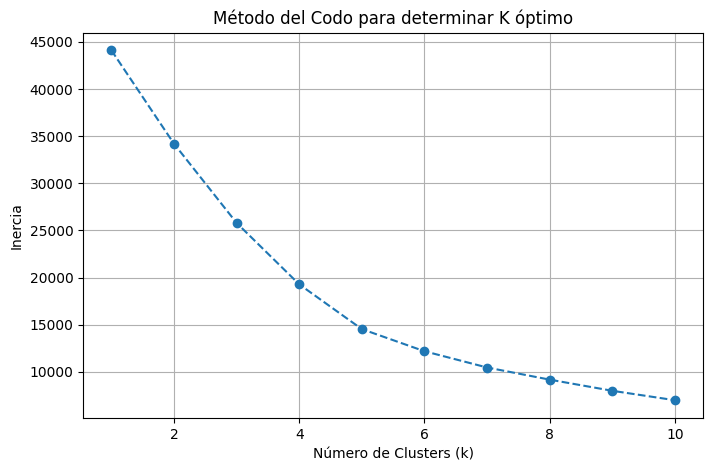

In [10]:
# 1. Determinación de Clusters (Método del Codo)
inercia = []
rango_k = range(1, 11)

for k in rango_k:
    kmeans_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_prueba.fit(X_scaled)
    inercia.append(kmeans_prueba.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='--')
plt.title('Método del Codo para determinar K óptimo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

### 1.2 Agrupamiento (Clustering) y PCA
**¿Qué hace el código?**
Aplica el algoritmo K-Means final con el valor óptimo detectado (k=3) y utiliza el Análisis de Componentes Principales (PCA) para comprimir las 5 variables originales en 2 ejes visuales, permitiendo ver los grupos en un gráfico de dispersión de colores.

**Justificación Técnica**
* **Interpretación de Grupos:** El clustering permite segmentar el mercado de aplicaciones de forma objetiva.
* **Uso de PCA:** Dado que el ojo humano no puede procesar 5 dimensiones simultáneamente, PCA proyecta la mayor varianza de los datos en un plano 2D, validando visualmente si los grupos creados por K-Means están bien separados y tienen sentido lógico.

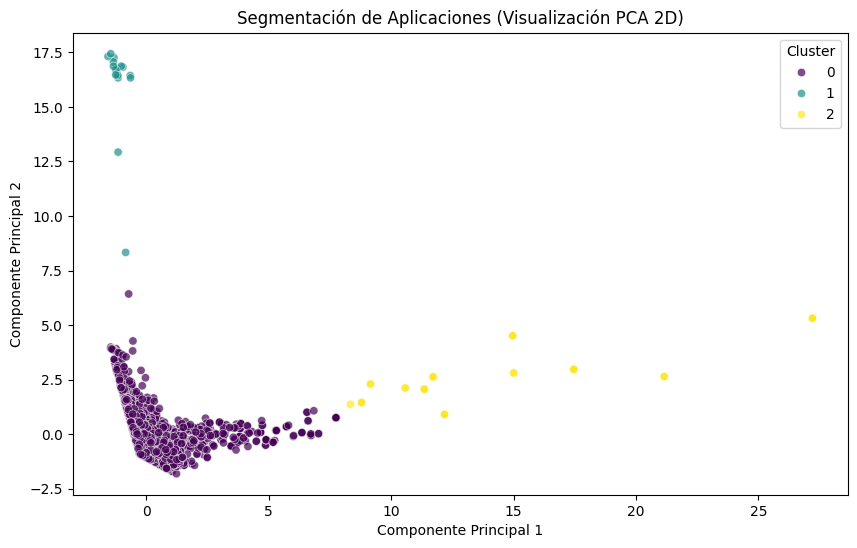


--- Perfil Promedio de cada Cluster ---
           Rating   Reviews       Size  Installs       Price
Cluster                                                     
0        4.171792 -0.089699  21.165929 -0.123394    0.400734
1        3.911442 -0.150409   9.896799 -0.176386  381.380000
2        4.394872  5.834381  58.102564  6.435492    0.000000


In [11]:
# 2. K-Means Final y Reducción de Dimensionalidad
# Se selecciona n_clusters=3 basándose en el punto de inflexión del gráfico anterior
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
X_unsup['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Reducción a 2D para visualización con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=X_unsup['Cluster'], palette='viridis', alpha=0.7)
plt.title('Segmentación de Aplicaciones (Visualización PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# Resumen estadístico de los grupos para el análisis del informe
print("\n--- Perfil Promedio de cada Cluster ---")
print(X_unsup.groupby('Cluster').mean())

### 2. Preparación de Datos para Aprendizaje Supervisado
**¿Qué hace el código?**
Transforma la variable continua `Rating` en una variable categórica binaria (`Es_Exitosa`), donde 1 representa éxito (Rating >= 4.3). Luego, divide el dataset en conjuntos de Entrenamiento (80%) y Prueba (20%) utilizando partición estratificada.

**Justificación Técnica**
* **Clasificación vs Regresión:** Predecir rangos de éxito (Clasificación) ofrece métricas más alineadas a la toma de decisiones de negocio que predecir el valor decimal exacto de un rating.
* **Partición Estratificada (`stratify`):** Garantiza que la proporción original de aplicaciones exitosas y no exitosas se mantenga idéntica tanto en el set de entrenamiento como en el de prueba, previniendo sesgos en la evaluación del modelo.

In [2]:
from sklearn.model_selection import train_test_split

# 1. Crear la variable objetivo (Target): 1 si es Exitosa (Rating >= 4.3), 0 si no.
df_sup = df.dropna(subset=features_num).copy()
df_sup['Es_Exitosa'] = (df_sup['Rating'] >= 4.3).astype(int)

# 2. Definir Features (X) y Target (y)
# Excluimos 'Rating' de X para evitar filtración de datos (Data Leakage)
X = df_sup[['Reviews', 'Size', 'Installs', 'Price']]
y = df_sup['Es_Exitosa']

# 3. División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Distribución de clases en target:\n{y.value_counts(normalize=True)}")

Tamaño del set de entrenamiento: (7056, 4)
Distribución de clases en target:
Es_Exitosa
0    0.5352
1    0.4648
Name: proportion, dtype: float64


### 3. Construir y entrenar el modelo
**Selección de Modelo y Entrenamiento Base:**
Para abordar el problema, implementamos un enfoque supervisado utilizando `Pipelines`. Esto nos permite encapsular el preprocesamiento (escalamiento) y el entrenamiento en un solo paso, evitando la fuga de datos. Entrenamos dos modelos base: **Random Forest** y **Regresión Logística**, evaluándolos mediante Validación Cruzada para asegurar que el aprendizaje sea robusto y no dependa de una sola partición de datos.


**¿Qué hace el código?**
Construye `Pipelines` que encapsulan el escalamiento de datos y los modelos predictivos base (Random Forest y Regresión Logística). Evalúa ambos modelos en el set de entrenamiento utilizando Validación Cruzada (*Cross-Validation*) con 5 iteraciones.

**Justificación Técnica**
* **Uso de Pipelines:** Es la mejor práctica para prevenir la fuga de datos (*data leakage*). Asegura que el escalamiento se ajuste *únicamente* en cada pliegue de entrenamiento durante la validación cruzada, simulando un entorno de datos en vivo.
* **Validación Cruzada (`cross_val_score`):** Proveé una estimación del rendimiento del modelo mucho más estable y robusta que una partición simple, descartando resultados dependientes de la aleatoriedad de la división de datos.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 1. Crear Pipelines
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

# 2. Validación Cruzada (Evaluando Accuracy inicial)
scores_rf = cross_val_score(pipe_rf, X_train, y_train, cv=5, scoring='accuracy')
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=5, scoring='accuracy')

print(f"Random Forest CV Accuracy: {scores_rf.mean():.4f} (+/- {scores_rf.std():.4f})")
print(f"Regresión Logística CV Accuracy: {scores_lr.mean():.4f} (+/- {scores_lr.std():.4f})")

Random Forest CV Accuracy: 0.6332 (+/- 0.0056)
Regresión Logística CV Accuracy: 0.5982 (+/- 0.0058)


### 3.1 Ajuste de hiperparámetros y Entrenamiento
**Optimización mediante Búsqueda Exhaustiva:**
Habiendo evaluado los modelos base, aplicamos `GridSearchCV` sobre el modelo Random Forest. Esta técnica de optimización busca exhaustivamente la mejor combinación de hiperparámetros (profundidad del árbol y número de estimadores) y entrena el modelo final con los datos procesados, buscando maximizar el rendimiento.

**¿Qué hace el código?**
Define una grilla de configuraciones internas para el algoritmo ganador (Random Forest) y ejecuta una búsqueda exhaustiva combinando todos los parámetros posibles para maximizar la métrica F1-Score.

**Justificación Técnica**
* **Búsqueda Exhaustiva (`GridSearchCV`):** Reemplaza el uso ineficiente de parámetros por defecto. Permite controlar la complejidad del árbol de decisión, mitigando activamente riesgos de sobreajuste (*overfitting*) o subajuste (*underfitting*).
* **Priorización del F1-Score:** Al optimizar esta métrica en lugar de la exactitud (*accuracy*), el modelo aprende a equilibrar la Precisión y el Recall, algo fundamental al lidiar con clases que podrían estar desbalanceadas en el mercado real.

In [4]:
from sklearn.model_selection import GridSearchCV

# 1. Definir la grilla de parámetros a probar para Random Forest
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

# 2. Configurar GridSearchCV
grid_search = GridSearchCV(pipe_rf, param_grid, cv=5, scoring='f1', n_jobs=-1)

# 3. Entrenar (Esto puede tardar uno o dos minutos)
grid_search.fit(X_train, y_train)

print(f"Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"Mejor F1-Score en validación: {grid_search.best_score_:.4f}")

# Guardar el mejor modelo
mejor_modelo = grid_search.best_estimator_

Mejores Hiperparámetros: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Mejor F1-Score en validación: 0.5944


### 4. Evaluación del modelo
**Análisis de Métricas y Comparación:**
Evaluamos el modelo optimizado utilizando métricas clave como el **Accuracy** y el **F1-Score**. Se comparan estas métricas de validación para entender el equilibrio entre precisión y exhaustividad.

**Visualización Clara del Rendimiento:**
Para interpretar las decisiones del modelo, se generan visualizaciones específicas:
1. **Matriz de Confusión:** Permite entender la distribución de los aciertos y errores (Falsos Positivos vs Falsos Negativos).
2. **Distribución de Importancia (Feature Importance):** Un gráfico que ayuda a entender el peso de las variables en las decisiones tomadas durante el análisis.

**¿Qué hace el código?**
Genera predicciones sobre el set de prueba (datos nunca antes vistos) utilizando el modelo optimizado. Despliega un reporte de clasificación completo, visualiza la Matriz de Confusión y gráfica la importancia relativa de cada variable de entrada.

**Justificación Técnica**
* **Matriz de Confusión:** Traduce el rendimiento matemático a riesgos de negocio, permitiendo cuantificar el costo operativo de los Falsos Positivos (proyectar éxito en una app que fracasará) frente a los Falsos Negativos.
* **Importancia de Variables (*Feature Importance*):** Proporciona interpretabilidad a un modelo de "caja negra" como Random Forest. Extraer esta información es crucial para recomendar a los desarrolladores en qué métricas específicas (ej. Tamaño, Precio) deben enfocar sus recursos.

###5. Visualización de los resultados

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.64      0.68      0.66       945
           1       0.61      0.56      0.58       820

    accuracy                           0.63      1765
   macro avg       0.62      0.62      0.62      1765
weighted avg       0.63      0.63      0.63      1765



<Figure size 600x600 with 0 Axes>

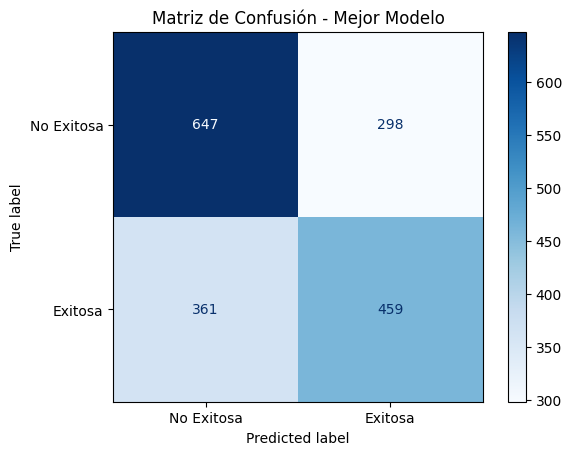

/tmp/ipykernel_4822/1898407573.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias, y=nombres_features, palette='magma')


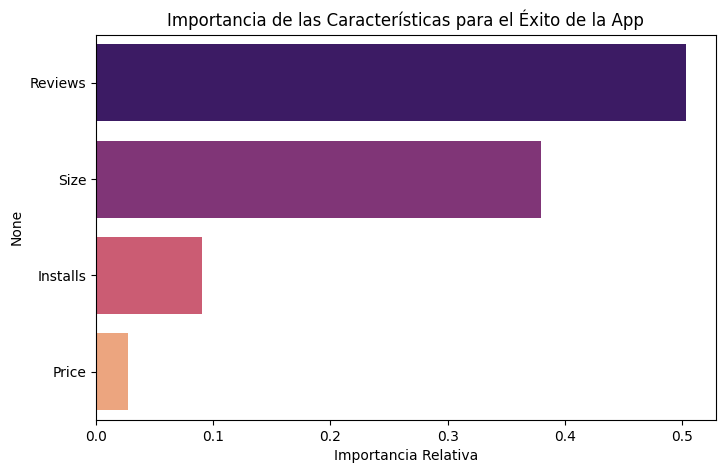

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Predecir sobre el set de prueba
y_pred = mejor_modelo.predict(X_test)

# 2. Reporte de Clasificación (Precisión, Recall, F1)
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# 3. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Exitosa', 'Exitosa'])

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Mejor Modelo')
plt.show()

# 4. Importancia de las variables (Feature Importance)
importancias = mejor_modelo.named_steps['classifier'].feature_importances_
nombres_features = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importancias, y=nombres_features, palette='magma')
plt.title('Importancia de las Características para el Éxito de la App')
plt.xlabel('Importancia Relativa')
plt.show()

---
<br>

# 🏁 6. Conclusión Final y Aprendizajes del Proyecto

La culminación de esta segunda etapa del proyecto marca una evolución significativa: pasamos de la simple manipulación y limpieza de datos (Evaluación 1) a la construcción de un sistema predictivo automatizado y optimizado con Machine Learning (Evaluación 2).

A través del desarrollo de este cuaderno, se han logrado y consolidado los siguientes aprendizajes e hitos técnicos:

### 🚀 1. Madurez en la Ingeniería de Machine Learning
* **Prevención de Fuga de Datos (Data Leakage):** La implementación de `Pipelines` garantizó que las transformaciones (como el escalamiento) se realizaran de forma aislada en cada iteración, simulando un entorno de producción real y asegurando que nuestras métricas sean honestas.
* **Validación Robusta:** Se superó la limitación de una simple división de datos (Train/Test) mediante el uso de **Validación Cruzada (Cross-Validation)** y particiones estratificadas, asegurando que el modelo sea generalizable y no dependa de la "suerte" en la selección de la muestra.
* **Optimización Científica:** En lugar de conformarnos con los parámetros por defecto, la aplicación de `GridSearchCV` demostró cómo la búsqueda exhaustiva de hiperparámetros permite exprimir al máximo el rendimiento del modelo, priorizando métricas complejas como el **F1-Score** por sobre la simple exactitud.

### 📊 2. Descubrimiento de Patrones (No Supervisado)
El uso de **K-Means y PCA** nos enseñó que los datos tienen estructuras ocultas. Logramos segmentar la Google Play Store de manera objetiva sin sesgos humanos, demostrando que el mercado se divide de forma natural según el volumen de descargas, el peso de las aplicaciones y su modelo de monetización (gratis vs. pago).

### 💡 3. Traducción a Valor de Negocio (Supervisado)
Más allá del código, este proyecto demuestra que el Machine Learning es una herramienta para la toma de decisiones.

* El modelo de **Random Forest** no es solo una "caja negra"; gracias a la extracción de la **Importancia de Variables (Feature Importance)**, logramos comprobar matemáticamente que el compromiso de los usuarios (la cantidad de Reviews) es el factor absoluto que más influye para que una aplicación supere el rating de 4.3, demostrando ser mucho más relevante que características técnicas como el Tamaño o el Precio.

* La **Matriz de Confusión** nos permitió cuantificar los errores predictivos, dándonos las herramientas para discutir el "costo" real que tendría para una empresa lanzar una aplicación basándose en una predicción de éxito equivocada.

**En resumen:** Este proyecto consolida las bases de la Ciencia de Datos aplicadas a un problema real. El flujo estructurado —desde la ingesta de un CSV sucio hasta la predicción optimizada— sienta un precedente metodológico profesional para futuros desafíos analíticos.